# Análisis Exploratorio del Mercado Accionario Chileno

Análisis de precios históricos de 9 acciones del IPSA distribuidas en 5 sectores (Mayo 2024 – Mayo 2026).

| Sector | Acciones |
|---|---|
| Retail | FALABELLA, CENCOSUD |
| Energía | COPEC, ENELCHILE |
| Banca | BSANTANDER, BCI |
| Minería / Forestal | CAP, CMPC |
| Utilities | AGUAS-A |

Se calculan retornos acumulados, retornos diarios, estadística descriptiva, Sharpe ratio y matriz de correlación para caracterizar el comportamiento de cada activo y sector.

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, jarque_bera
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

## 1. Carga de datos

Se descargan 2 años de precios de cierre diarios para 9 acciones del IPSA usando Yahoo Finance, junto con el ETF ECH como benchmark. Los precios se alinean por fecha usando reindex con forward-fill para manejar días sin transacción en el mercado chileno.

In [2]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")
lista_nombre_acciones.append("ECH")
ech = yf.download("ECH", period="2y")["Close"]


[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
precios_cierre = datos_brutos_acciones["Close"].copy()
precios_cierre["ECH"] = ech.reindex(precios_cierre.index).ffill().bfill()
precios_cierre

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN,ECH
Date,,,,,,,,,,
2024-05-20,248.459351,25613.064453,40.331642,6665.000000,1815.368164,1913.479980,7242.274414,48.442776,2718.494873,27.301796
2024-05-22,249.061478,25499.734375,40.828449,6586.000000,1815.466553,1898.608398,7481.546875,48.518719,2669.521973,27.301796
2024-05-23,249.982895,25547.900391,41.009106,6542.000000,1844.986328,1938.860962,7530.638184,49.058750,2688.727051,27.510353
2024-05-24,251.798386,25518.623047,40.882641,6683.299805,1832.489624,1942.231812,7530.638184,49.549168,2627.750488,27.643068
2024-05-27,251.798386,25317.458984,40.918777,6735.000000,1837.409668,1951.154663,7669.076172,49.811863,2602.303711,27.643068
...,...,...,...,...,...,...,...,...,...,...
2026-05-14,316.000000,57253.000000,69.099998,6700.000000,2125.000000,1065.000000,6150.000000,77.189110,5441.500000,40.139999
2026-05-15,324.000000,59193.000000,68.989998,6607.500000,2060.000000,1055.000000,6145.000000,76.809998,5500.200195,39.240002
2026-05-18,329.989990,59600.000000,69.169998,6550.000000,2106.000000,1061.000000,6450.000000,76.800003,5650.000000,39.830002


## 2. Retornos acumulados y comparación de rendimiento

Se calcula el retorno porcentual acumulado de cada acción desde el inicio del período. Los precios se normalizan a base 100 y luego se les resta 100, de modo que todas las series parten desde 0% y reflejan directamente la ganancia o pérdida que habría obtenido un inversionista que compró en mayo 2024.

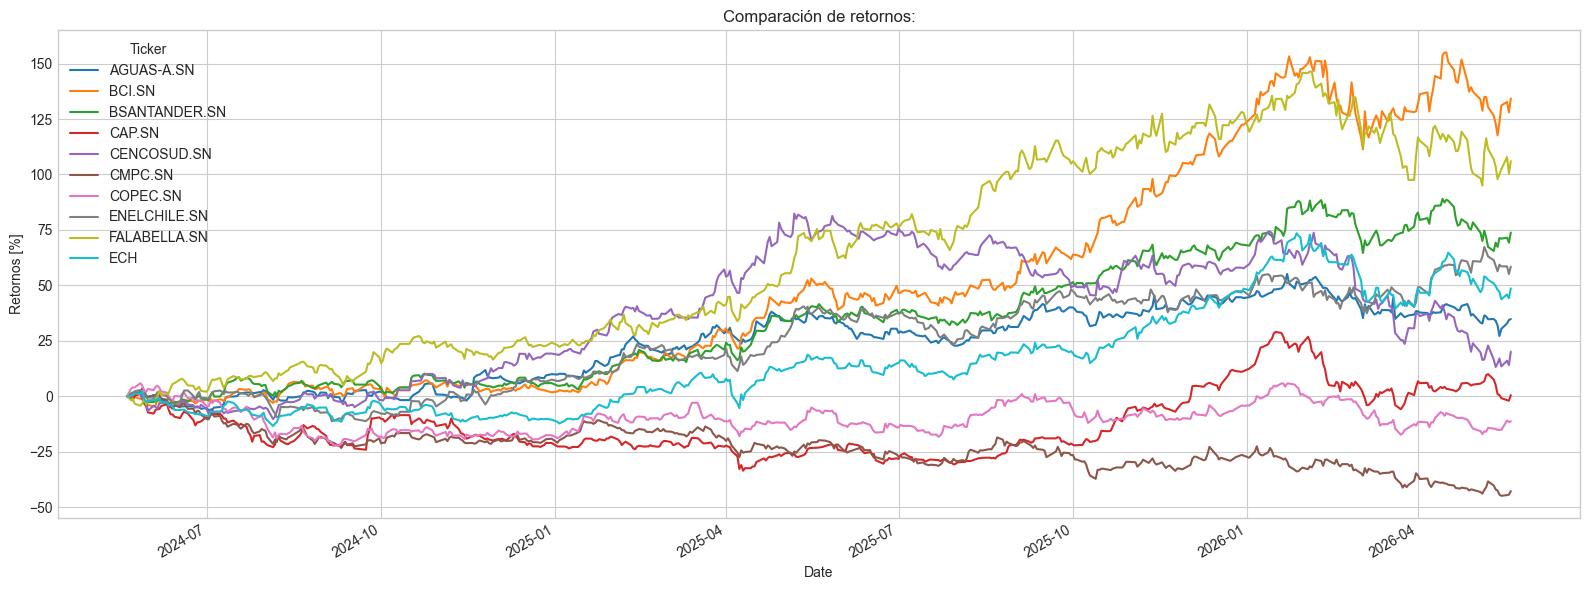

In [4]:
precios_normalizados = precios_cierre/precios_cierre.iloc[0]*100
retornos_en_tiempo = precios_normalizados - 100
plt.style.use('seaborn-v0_8-whitegrid')
fig, rt_g = plt.subplots(figsize=(16, 6))
rt_g.set_title('Retornos acumulados — 9 acciones IPSA vs ECH (Mayo 2024 – Mayo 2026)')
rt_g.set_xlabel("Fecha")
rt_g.set_ylabel("Retornos [%]")
retornos_en_tiempo.plot(ax=rt_g)
plt.tight_layout()

### 2.1 Comparación relativa al benchmark

Se utiliza ECH (iShares MSCI Chile ETF) como proxy del mercado chileno, dado que `^IPSA` no tiene datos históricos disponibles vía yfinance. Se calcula la diferencia de retorno acumulado de cada acción respecto al ETF, para identificar qué activos generaron alpha y cuáles quedaron por debajo del mercado.

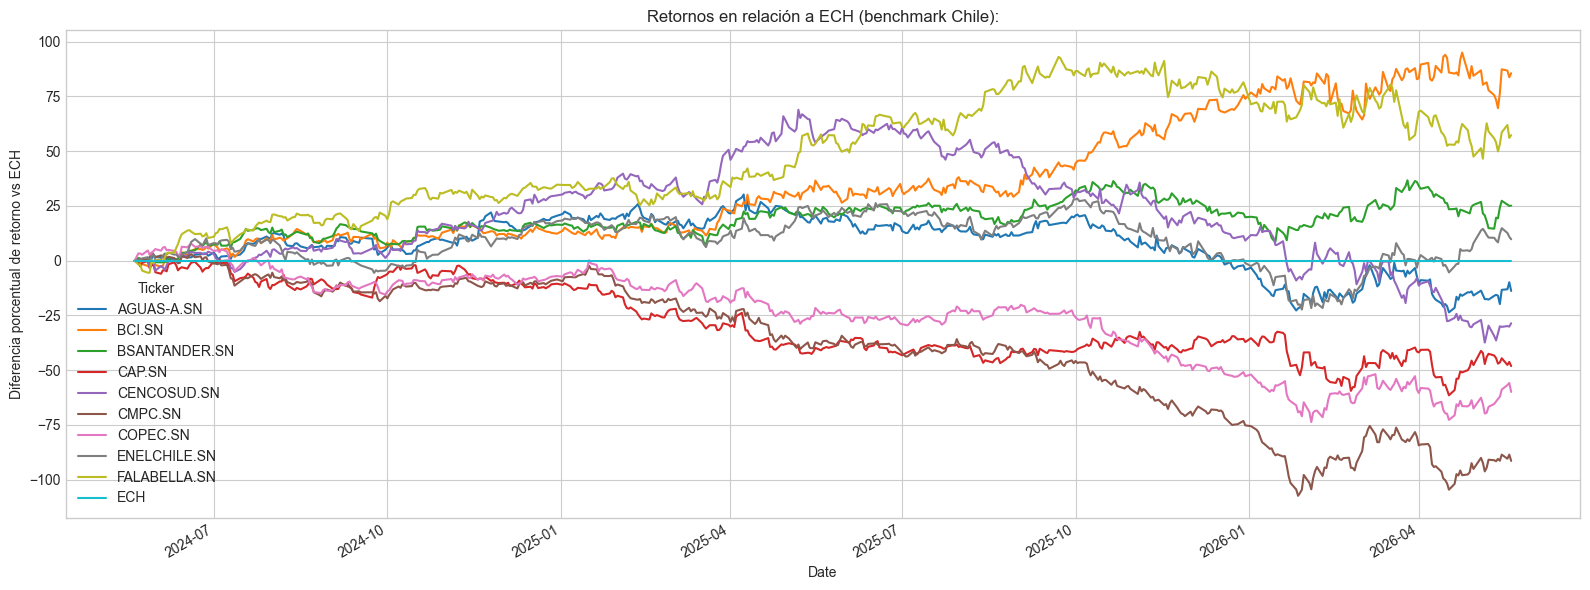

In [5]:
benchmark = retornos_en_tiempo["ECH"]
retornos_con_bchmk = retornos_en_tiempo.sub(benchmark, axis=0)
fig, gf_bk = plt.subplots(figsize=(16, 6))
gf_bk.set_title("Retorno acumulado relativo al benchmark ECH")
gf_bk.set_ylabel("Diferencia porcentual de retorno vs ECH")
retornos_con_bchmk.plot(ax=gf_bk)
plt.tight_layout()

## 3. Retornos diarios y estadística descriptiva

Los retornos diarios se calculan con `pct_change()` sobre los precios de cierre. Se reportan media, volatilidad (desviación estándar), ratio de Sharpe simplificado (retorno/volatilidad, sin tasa libre de riesgo) y exceso de kurtosis como indicador de fat tails.

In [6]:
retornos_diarios = precios_cierre.pct_change().dropna()
retornos_diarios

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN,ECH
Date,,,,,,,,,,
2024-05-22,0.002423,-0.004425,0.012318,-0.011853,0.000054,-0.007772,0.033038,0.001568,-0.018015,0.000000
2024-05-23,0.003700,0.001889,0.004425,-0.006681,0.016260,0.021201,0.006562,0.011130,0.007194,0.007639
2024-05-24,0.007262,-0.001146,-0.003084,0.021599,-0.006773,0.001739,0.000000,0.009997,-0.022679,0.004824
2024-05-27,0.000000,-0.007883,0.000884,0.007736,0.002685,0.004594,0.018383,0.005302,-0.009684,0.000000
2024-05-28,-0.014493,0.001977,-0.013907,-0.022272,-0.020993,0.016260,-0.010229,-0.010911,0.009963,0.009259
...,...,...,...,...,...,...,...,...,...,...
2026-05-14,-0.036585,0.027015,0.023855,-0.004458,0.020114,-0.031818,0.001058,0.019108,0.011431,-0.006682
2026-05-15,0.025316,0.033885,-0.001592,-0.013806,-0.030588,-0.009390,-0.000813,-0.004911,0.010788,-0.022421
2026-05-18,0.018488,0.006876,0.002609,-0.008702,0.022330,0.005687,0.049634,-0.000130,0.027235,0.015036


In [20]:
sharpe = retornos_diarios.mean()/retornos_diarios.std()
media = retornos_diarios.mean()
dst = retornos_diarios.std()

pd.DataFrame({"Media diaria" : media, "Media anual" : media * 252,"Desviación Estándar Diaria" : dst, "Desviación Estándar Anual" : dst * np.sqrt(252), "Ratio de Sharpe diario" : sharpe, "Ratio de Sharpe anual" : sharpe * np.sqrt(252),  "Retorno Acumulado (%)" : retornos_en_tiempo.iloc[-1], "Kurtosis" : retornos_diarios.kurt()}).sort_values("Retorno Acumulado (%)", ascending = False)

,Media diaria,Media anual,Desviación Estandar diaria,Desviación Estandar diaria anual,Ratio de Sharpe diario,Ratio de Sharpe anual,Porcentaje de Retorno,Kurtosis
Ticker,,,,,,,,
BCI.SN,0.001847,0.465387,0.015899,0.252385,0.116158,1.843956,134.255452,1.495529
FALABELLA.SN,0.001605,0.404569,0.017030,0.270337,0.094273,1.496538,105.996342,1.002265
BSANTANDER.SN,0.001196,0.301494,0.012594,0.199920,0.095000,1.508075,73.808937,1.184181
ENELCHILE.SN,0.001030,0.259564,0.014172,0.224974,0.072680,1.153751,58.434357,1.013831
ECH,0.000905,0.228081,0.014396,0.228532,0.062870,0.998027,48.671539,1.922926
AGUAS-A.SN,0.000679,0.171155,0.012288,0.195064,0.055273,0.877427,34.830909,5.071737
CENCOSUD.SN,0.000508,0.128031,0.016659,0.264449,0.030498,0.484142,20.085834,1.682970
CAP.SN,0.000148,0.037365,0.016618,0.263804,0.008923,0.141641,0.525131,2.628357
COPEC.SN,-0.000128,-0.032317,0.015101,0.239714,-0.008492,-0.134814,-11.284776,0.509304


## 4. Distribución de retornos — leptokurtosis

Se compara la distribución empírica de retornos (KDE) con la distribución normal teórica de igual media y desviación estándar para cada acción. Las diferencias entre ambas curvas revelan si los retornos presentan colas más gruesas de lo que la normal predice.

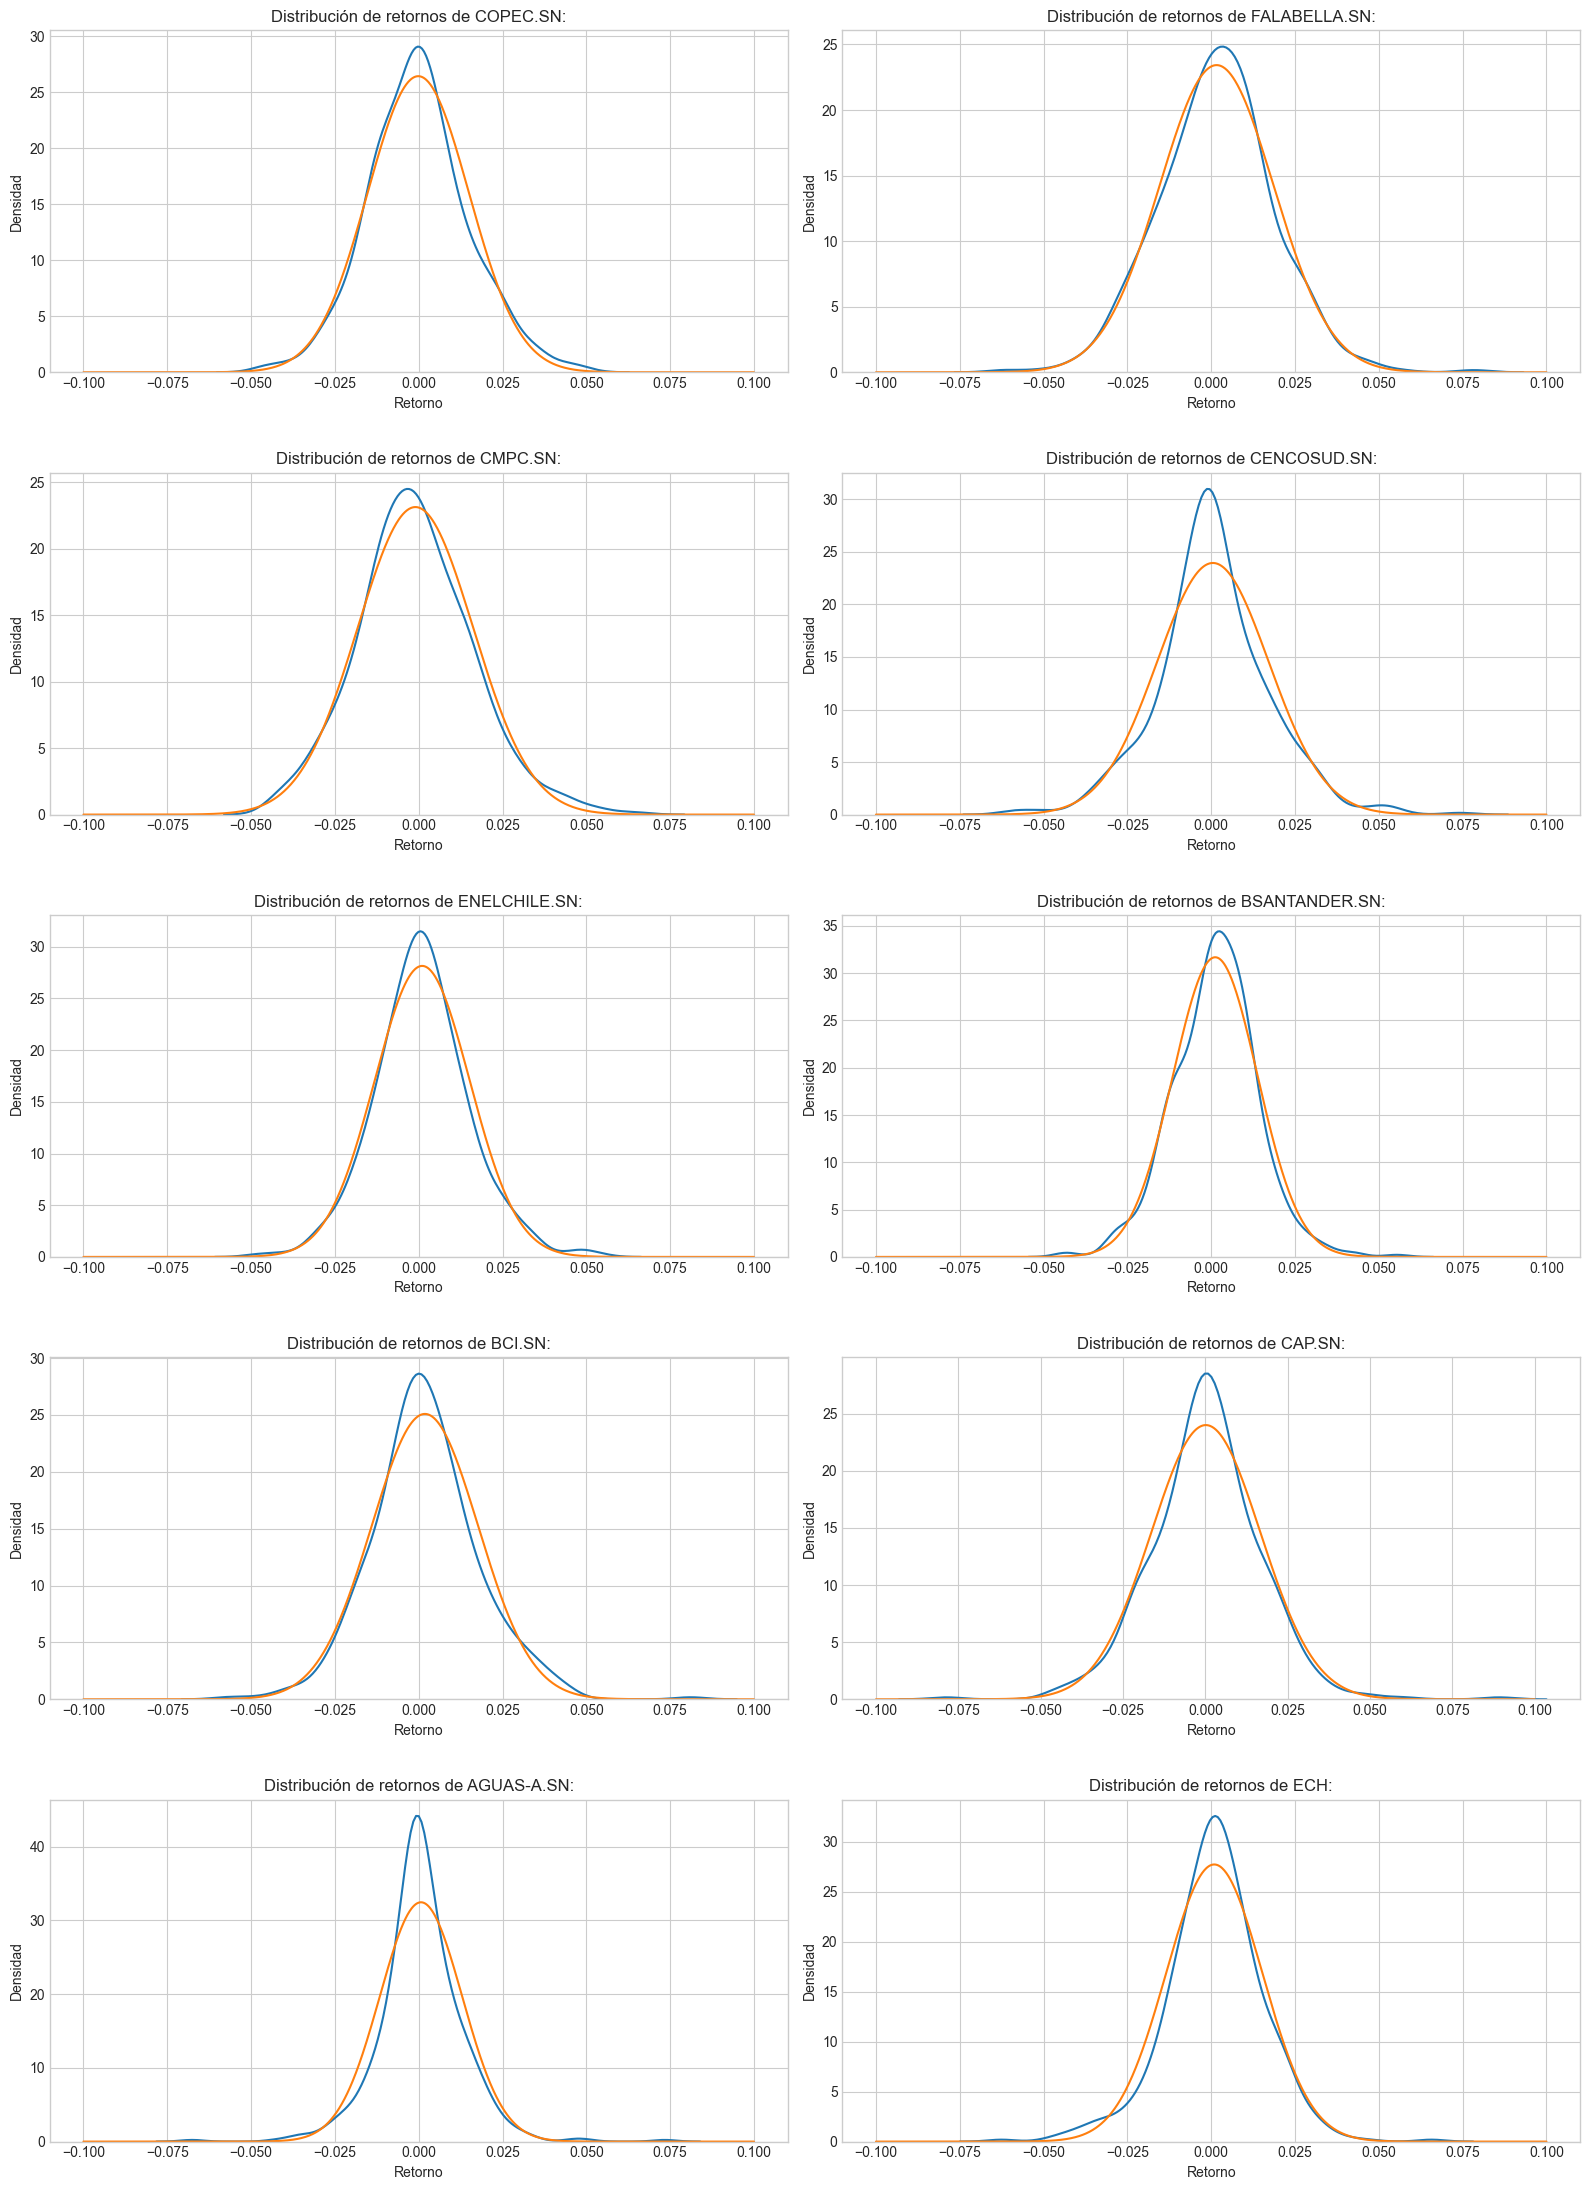

In [8]:
fig, gauss_retornos = plt.subplots(5, 2, figsize=(16, 22))
x = 0
y = 0

for i in lista_nombre_acciones:
    x_valores = np.linspace(-0.1, 0.1, 1000)
    densidad_normal = norm.pdf(x_valores, loc=media[i], scale=dst[i])
    sns.kdeplot(retornos_diarios[i], ax=gauss_retornos[x][y])
    gauss_retornos[x][y].set_title("Distribución de retornos de " + i + ":")
    gauss_retornos[x][y].set_ylabel("Densidad")
    gauss_retornos[x][y].set_xlabel("Retorno")
    gauss_retornos[x][y].plot(x_valores, densidad_normal)
    if y == 1:
        x += 1
        y = 0
    else:
        y += 1

plt.tight_layout(h_pad=3)

In [9]:
dic_jaque = {}
for i in lista_nombre_acciones:
    dic_jaque[i] = jarque_bera(retornos_diarios[i])
pd.DataFrame(dic_jaque).T.rename(columns={0: "Estadístico JB", 1: "p-value"})

,Estadístico JB,p-value
COPEC.SN,7.797118,2.027111e-02
FALABELLA.SN,20.603033,3.358214e-05
CMPC.SN,13.785934,1.014898e-03
CENCOSUD.SN,58.881239,1.637199e-13
ENELCHILE.SN,24.167622,5.650249e-06
BSANTANDER.SN,27.899611,8.743321e-07
BCI.SN,50.040875,1.360699e-11
CAP.SN,139.508761,5.082268e-31
AGUAS-A.SN,518.516512,2.544310e-113
ECH,78.765474,7.875801e-18


## 5. Autocorrelación de retornos y eficiencia de mercado

Se grafica el retorno del día `t` contra el retorno del día `t+1` para cada acción. La existencia de estructura en el scatter indicaría que el retorno de hoy predice el de mañana — lo cual sería inconsistente con la Hipótesis de Mercado Eficiente (EMH) en su forma débil.

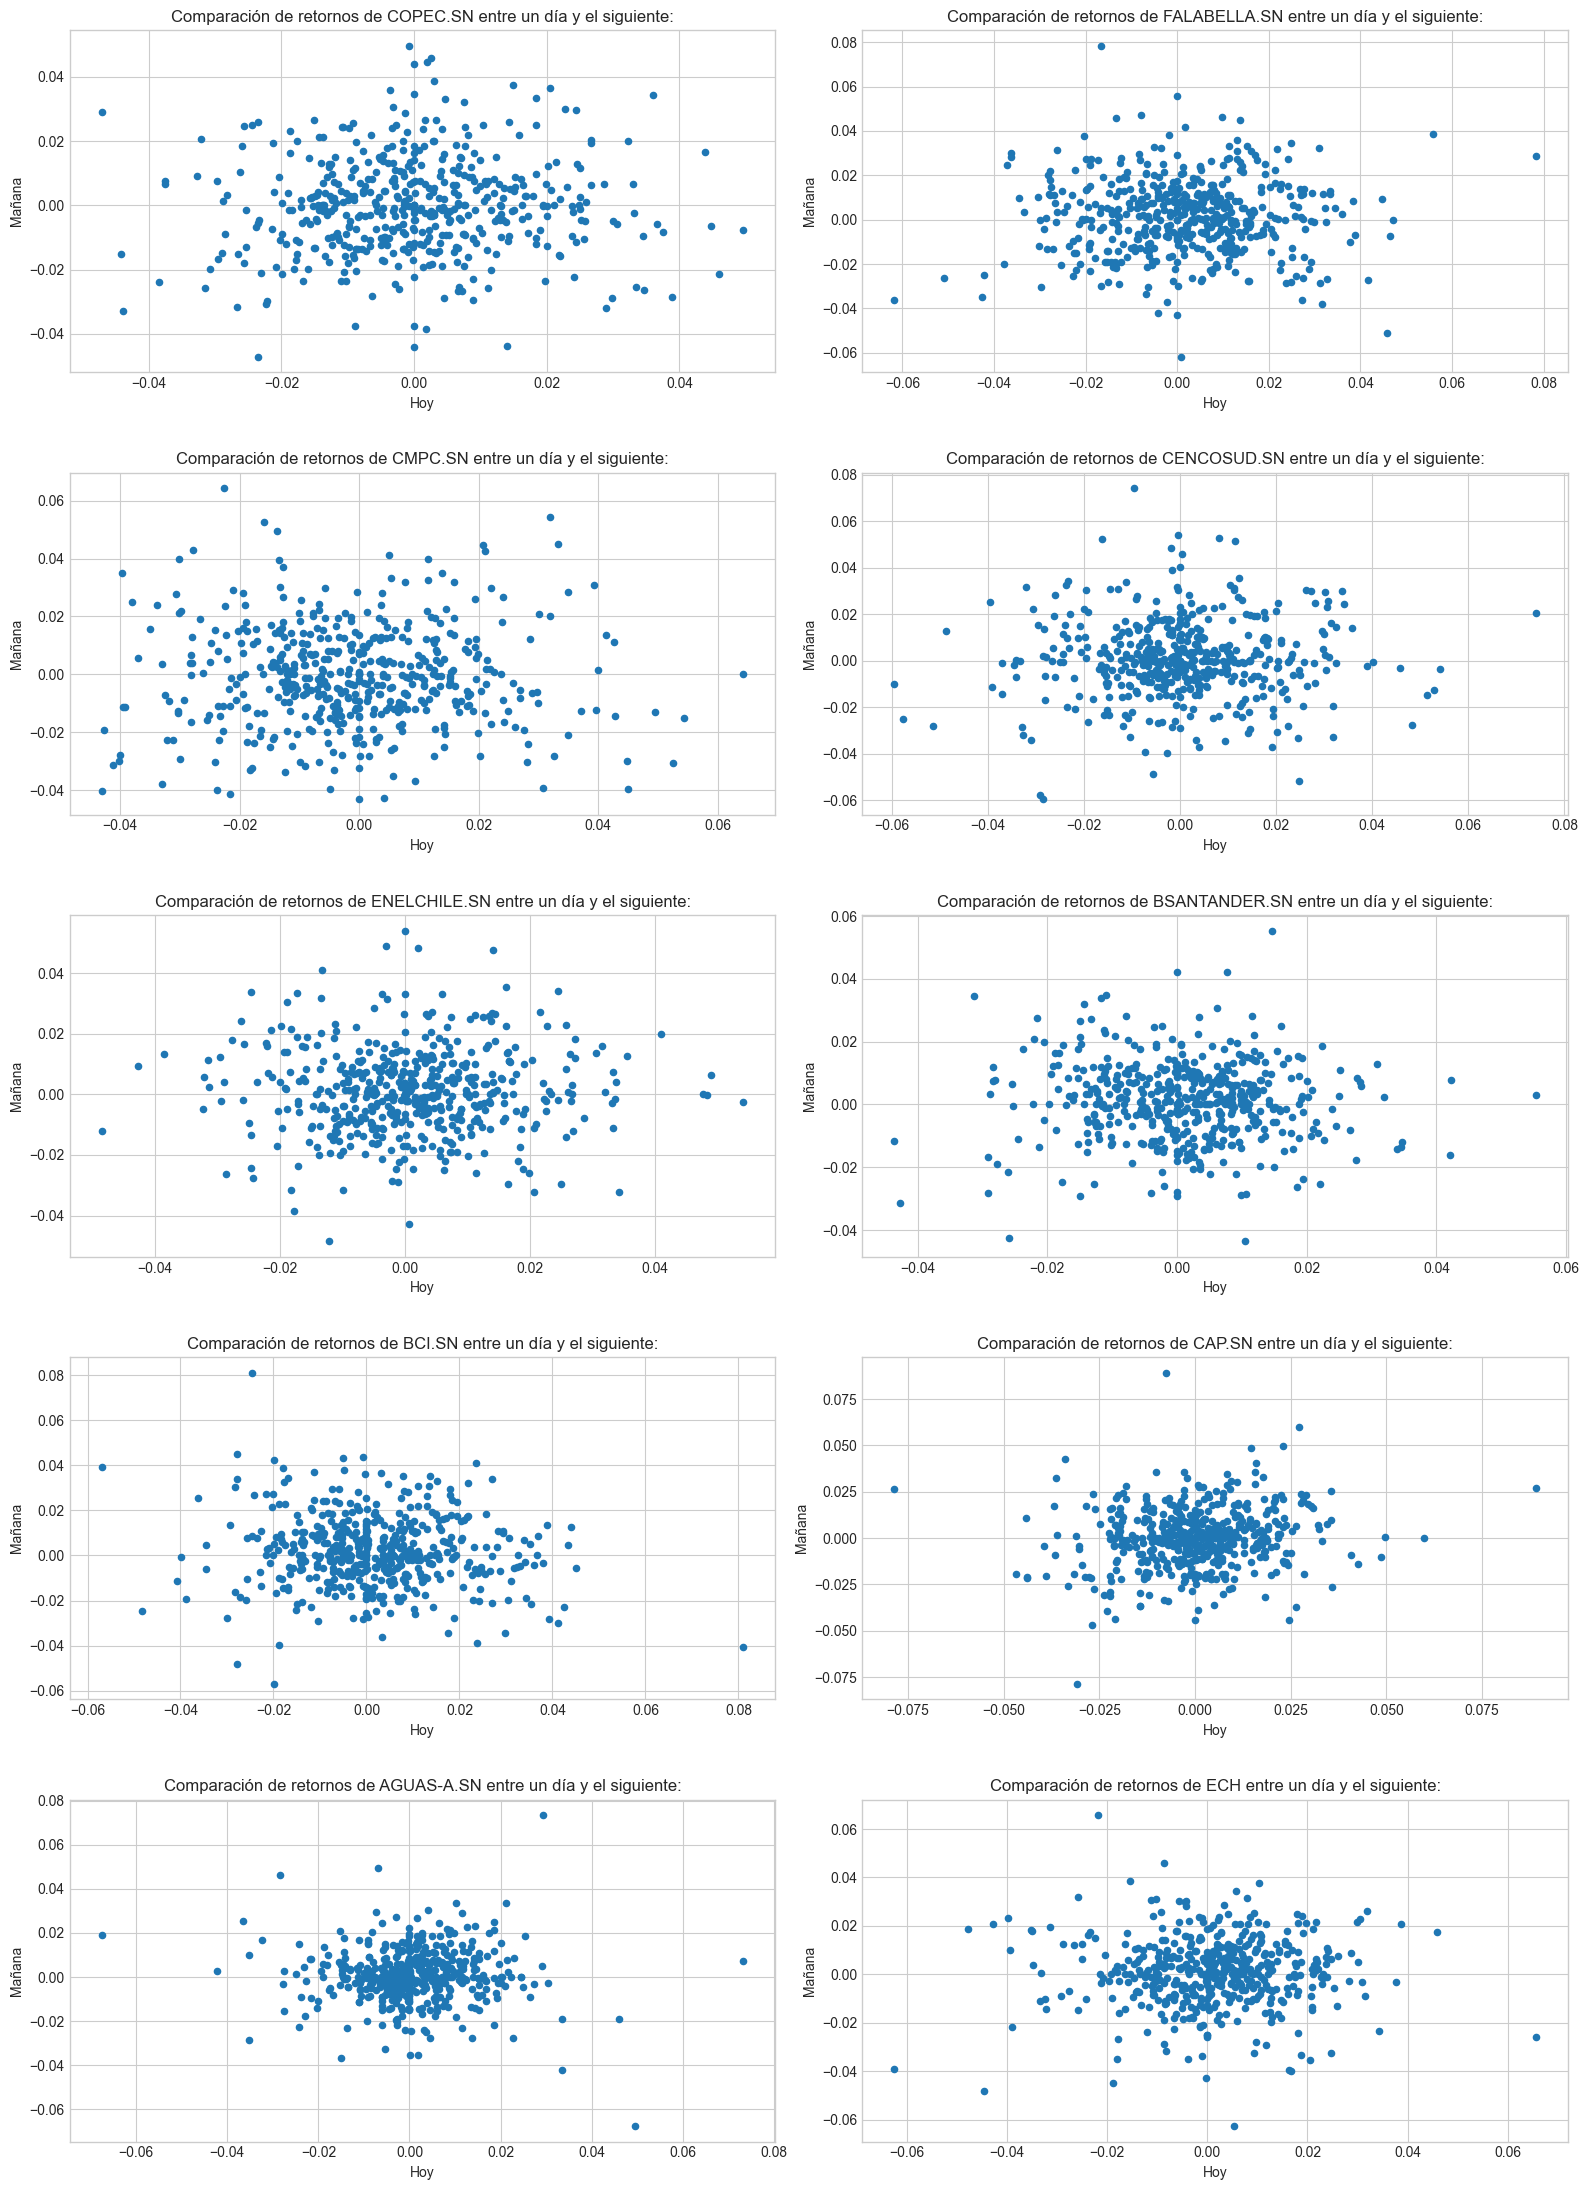

In [10]:
x = 0
y = 0
fig, comparacion_retorno_hoy_mañana = plt.subplots(5, 2, figsize=(16, 22))
for i in lista_nombre_acciones:
    retornos_dia_siguiente_ac_es = retornos_diarios[i].shift(-1)
    retornos_diarios_ac_es = retornos_diarios[i]
    comparacion_retorno_hoy_mañana[x][y].set_title("Comparación de retornos de " + i + " entre un día y el siguiente:")
    comparacion_ax = pd.DataFrame({"Hoy": retornos_diarios_ac_es, "Mañana": retornos_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x="Hoy", y="Mañana", ax=comparacion_retorno_hoy_mañana[x][y])
    if y == 1:
        x += 1
        y = 0
    else:
        y += 1

plt.tight_layout(h_pad=3)

### 5.1 Test formal de autocorrelación — Ljung-Box

El análisis visual sugiere ausencia de estructura. Se aplica el test Ljung-Box (lag=1) para cuantificar formalmente si la autocorrelación observada es estadísticamente distinguible del ruido. H₀: los retornos son independientes entre días consecutivos.

In [11]:
dic_ljung_stat = {}
dic_ljung_pvalue = {}
for i in lista_nombre_acciones:
    lj = acorr_ljungbox(retornos_diarios[i], lags=1)
    dic_ljung_stat[i] = float(lj["lb_stat"].values[0])
    dic_ljung_pvalue[i] = float(lj["lb_pvalue"].values[0])
pd.DataFrame({"Ljung-Box" : dic_ljung_stat, "p-value" : dic_ljung_pvalue})

,Ljung-Box,p-value
COPEC.SN,1.214235,0.270495
FALABELLA.SN,0.236883,0.626466
CMPC.SN,0.015009,0.902493
CENCOSUD.SN,0.513503,0.473626
ENELCHILE.SN,0.154903,0.693893
BSANTANDER.SN,1.103331,0.293536
BCI.SN,4.902696,0.026815
CAP.SN,11.586181,0.000664
AGUAS-A.SN,0.465000,0.495296
ECH,0.009566,0.922087


## 6. Agrupamiento de volatilidad

A diferencia de los retornos, la magnitud de los movimientos puede ser persistente. Se grafica el valor absoluto del retorno del día `t` contra el del día `t+1` para detectar si los días volátiles tienden a agruparse con otros días volátiles.

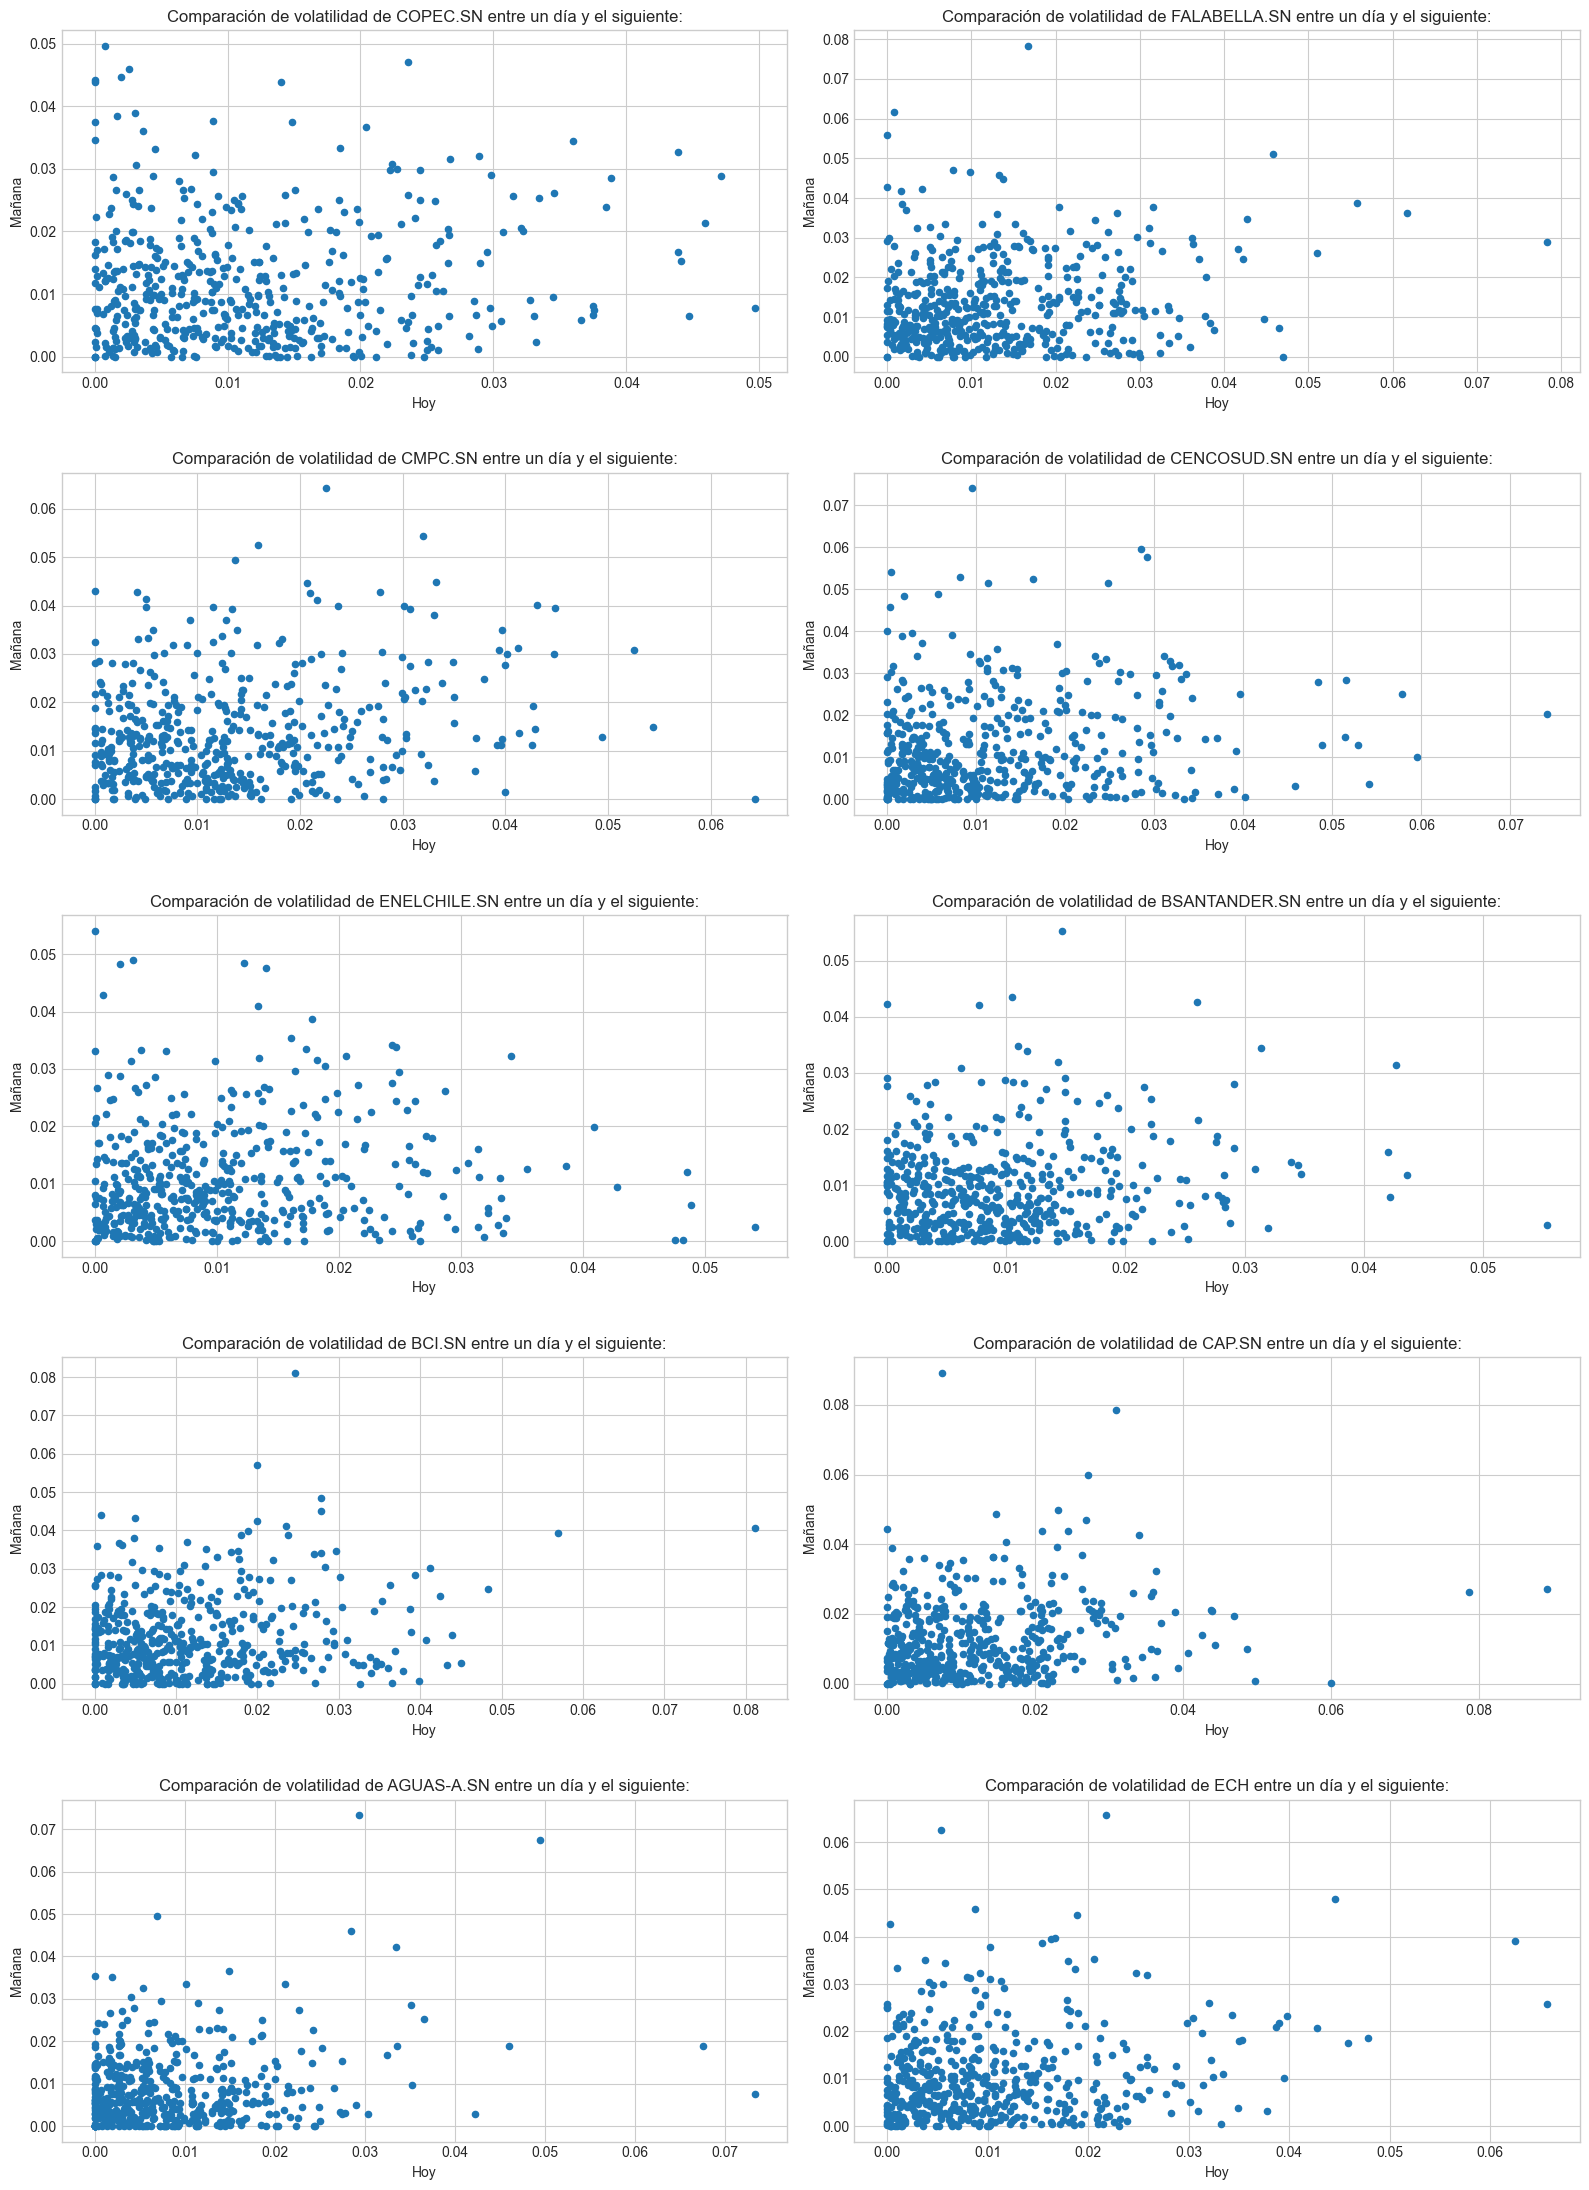

In [12]:
volatilidad_diarios = abs(retornos_diarios)
x = 0
y = 0
fig, comparacion_volatilidad_hoy_mañana = plt.subplots(5, 2, figsize=(16, 22))
for i in lista_nombre_acciones:
    volatilidad_dia_siguiente_ac_es = volatilidad_diarios[i].shift(-1)
    volatilidad_diarios_ac_es = volatilidad_diarios[i]
    comparacion_volatilidad_hoy_mañana[x][y].set_title("Comparación de volatilidad de " + i + " entre un día y el siguiente:")
    comparacion_ax = pd.DataFrame({"Hoy": volatilidad_diarios_ac_es, "Mañana": volatilidad_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x="Hoy", y="Mañana", ax=comparacion_volatilidad_hoy_mañana[x][y])
    if y == 1:
        x += 1
        y = 0
    else:
        y += 1

plt.tight_layout(h_pad=3)

## 7. Variación de retornos entre días no consecutivos

Se analiza si la aceleración del retorno en un par de días predice la aceleración en el siguiente par. Se usa una ventana sin solapamiento (`r_{t+1} - r_t` vs `r_{t+3} - r_{t+2}`) para evitar correlación espuria matemática por términos compartidos.

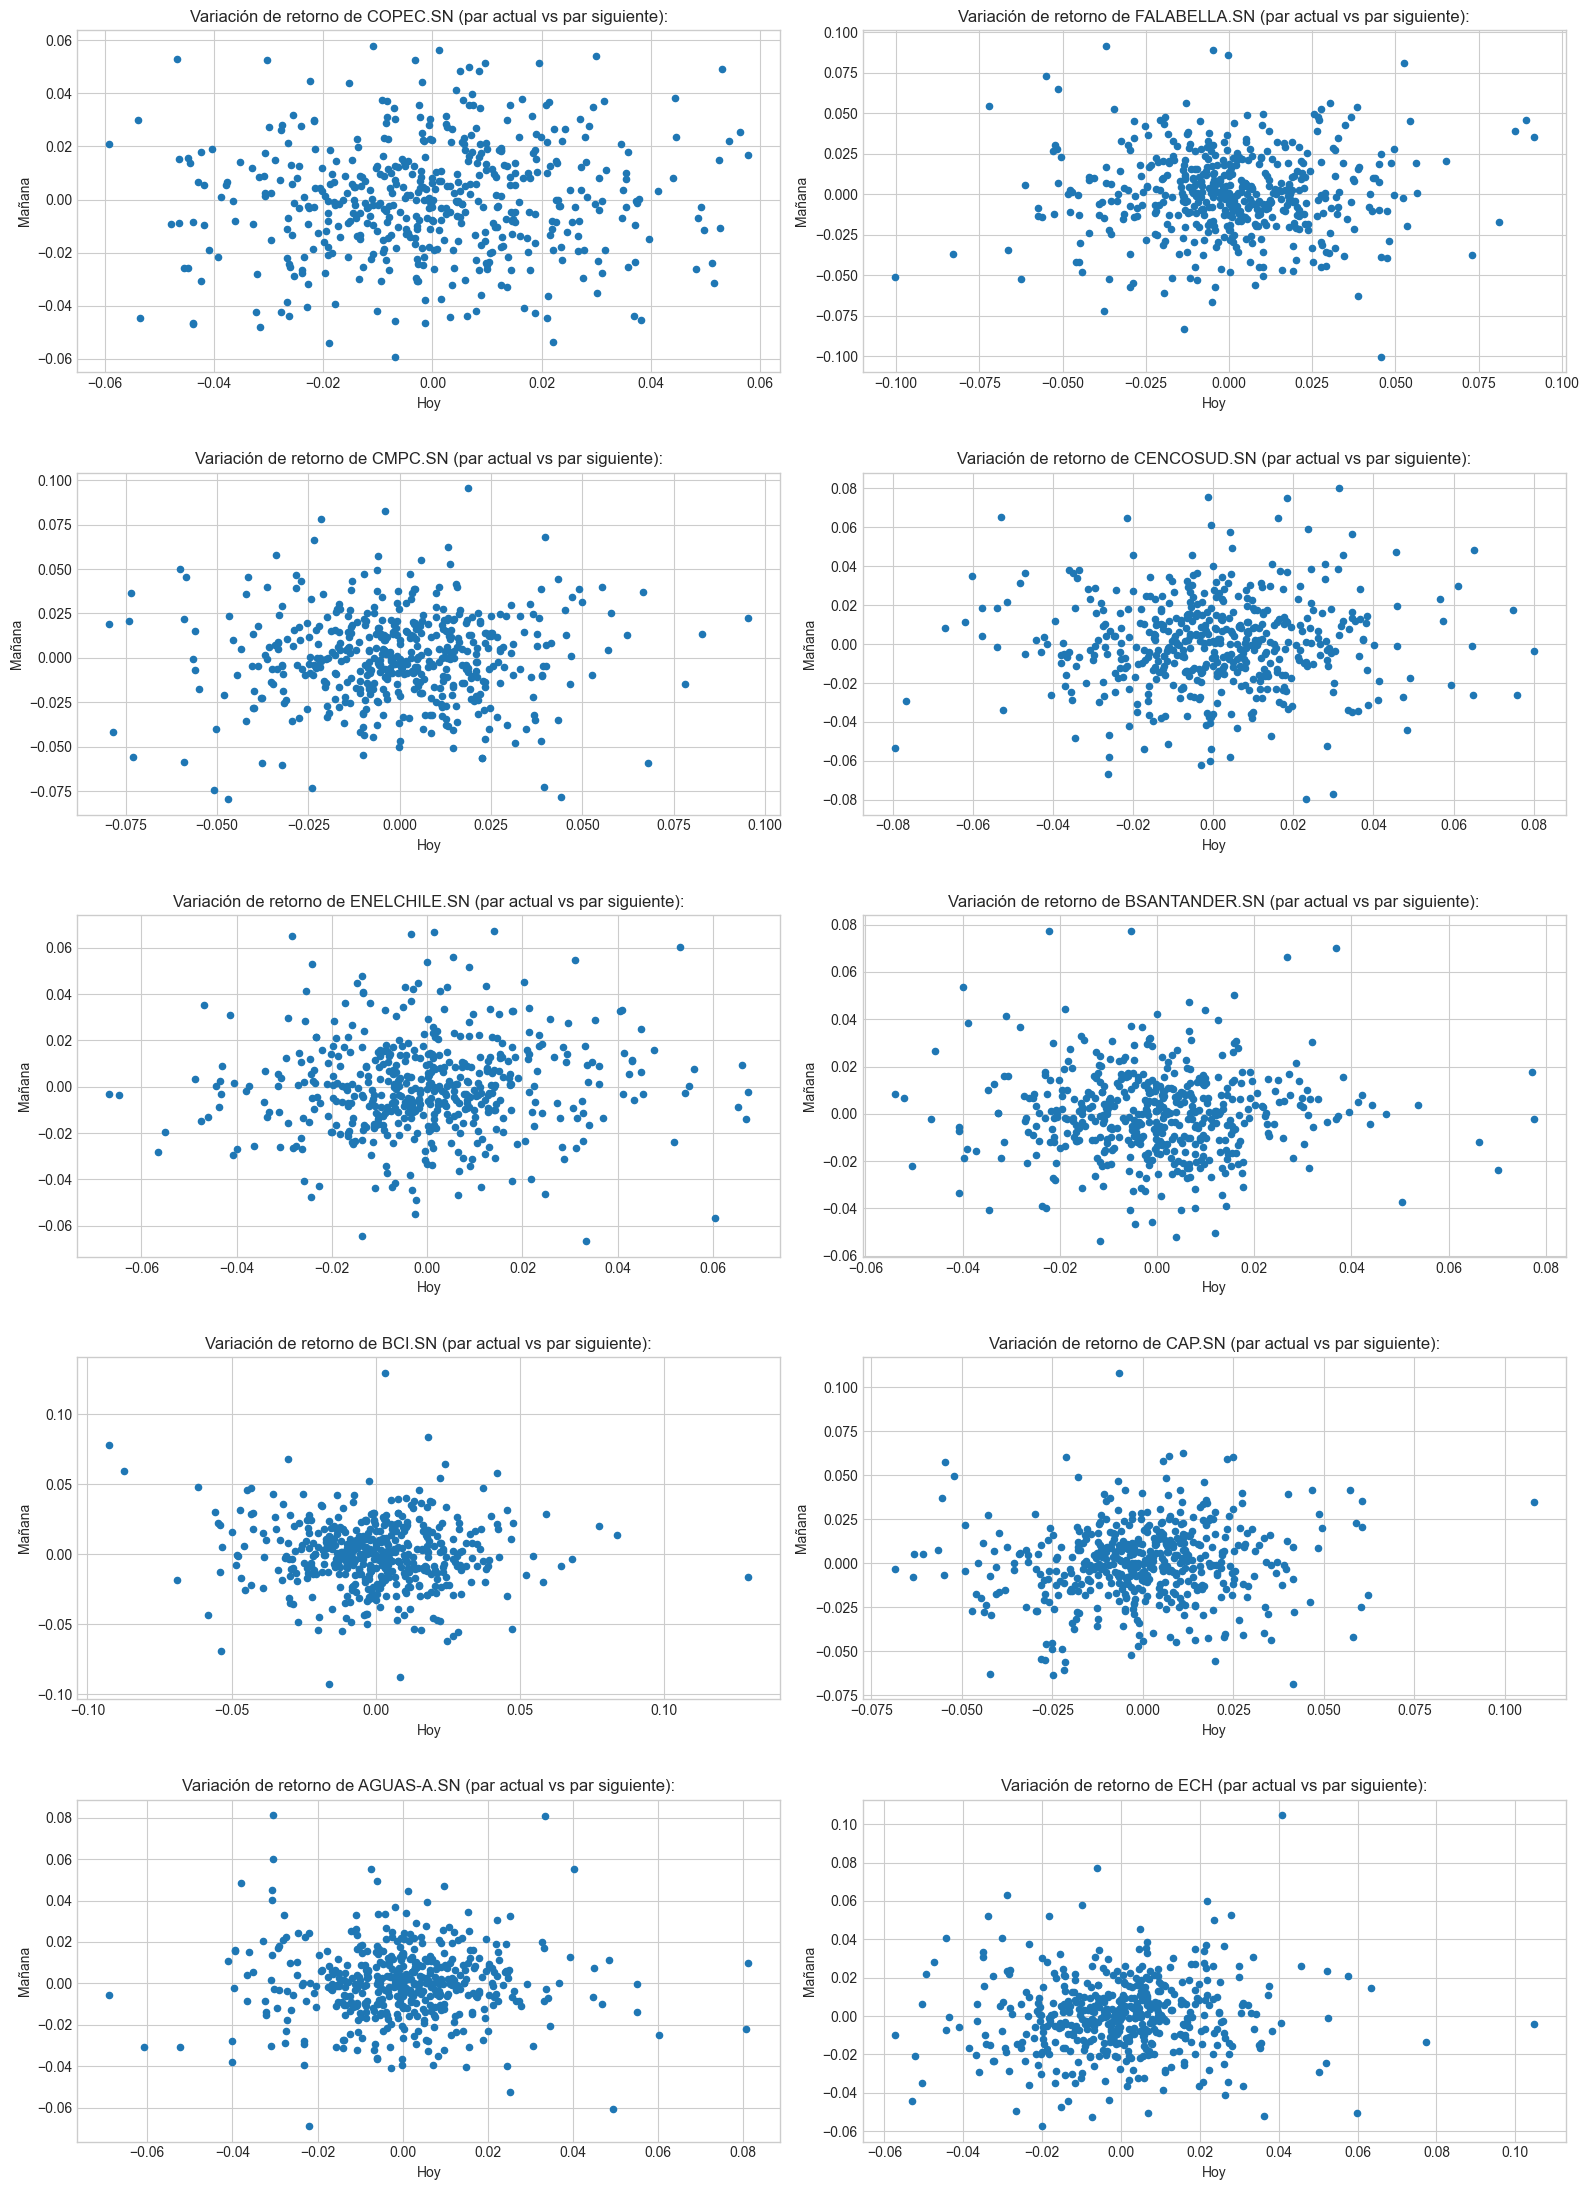

In [13]:
var_diarios = (retornos_diarios.shift(-2) - retornos_diarios)
x = 0
y = 0
fig, comparacion_var_hoy_mañana = plt.subplots(5, 2, figsize=(16, 22))
for i in lista_nombre_acciones:
    var_dia_siguiente_ac_es = var_diarios[i].shift(-1)
    var_diarios_ac_es = var_diarios[i]
    comparacion_var_hoy_mañana[x][y].set_title("Variación de retorno de " + i + " (par actual vs par siguiente):")
    comparacion_ax = pd.DataFrame({"Hoy": var_diarios_ac_es, "Mañana": var_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x="Hoy", y="Mañana", ax=comparacion_var_hoy_mañana[x][y])
    if y == 1:
        x += 1
        y = 0
    else:
        y += 1

plt.tight_layout(h_pad=3)

### 7.1 Test formal de variación en pares — Ljung-Box

Se aplica el test Ljung-Box sobre `var_diarios` (variación de retorno entre pares de días) para cuantificar formalmente si existe autocorrelación en la aceleración del retorno. H₀: la variación de retorno entre pares de días consecutivos es independiente.

In [18]:
dic_ljung_stat_v = {}
dic_ljung_pvalue_v = {}
for i in lista_nombre_acciones:
    lj_v = acorr_ljungbox(var_diarios[i].dropna(), lags=1)
    dic_ljung_stat_v[i] = float(lj_v["lb_stat"].values[0])
    dic_ljung_pvalue_v[i] = float(lj_v["lb_pvalue"].values[0])
pd.DataFrame({"Ljung-Box: Variación de retorno en pares" : dic_ljung_stat_v, "p-value" : dic_ljung_pvalue_v})

,Ljung-Box: Variación de retorno en pares,p-value
COPEC.SN,2.196180,0.138353
FALABELLA.SN,0.771987,0.379603
CMPC.SN,0.472389,0.491890
CENCOSUD.SN,0.511474,0.474501
ENELCHILE.SN,1.861025,0.172507
BSANTANDER.SN,0.011451,0.914781
BCI.SN,2.266877,0.132166
CAP.SN,5.758993,0.016404
AGUAS-A.SN,0.068398,0.793684
ECH,1.280467,0.257812


## 8. Correlación entre activos

La correlación entre retornos diarios mide qué tan relacionados están los movimientos de precio entre pares de activos. Valores cercanos a 1 indican que se mueven juntos; cercanos a 0, independencia. La estructura sectorial en la matriz orienta la diversificación del portafolio.

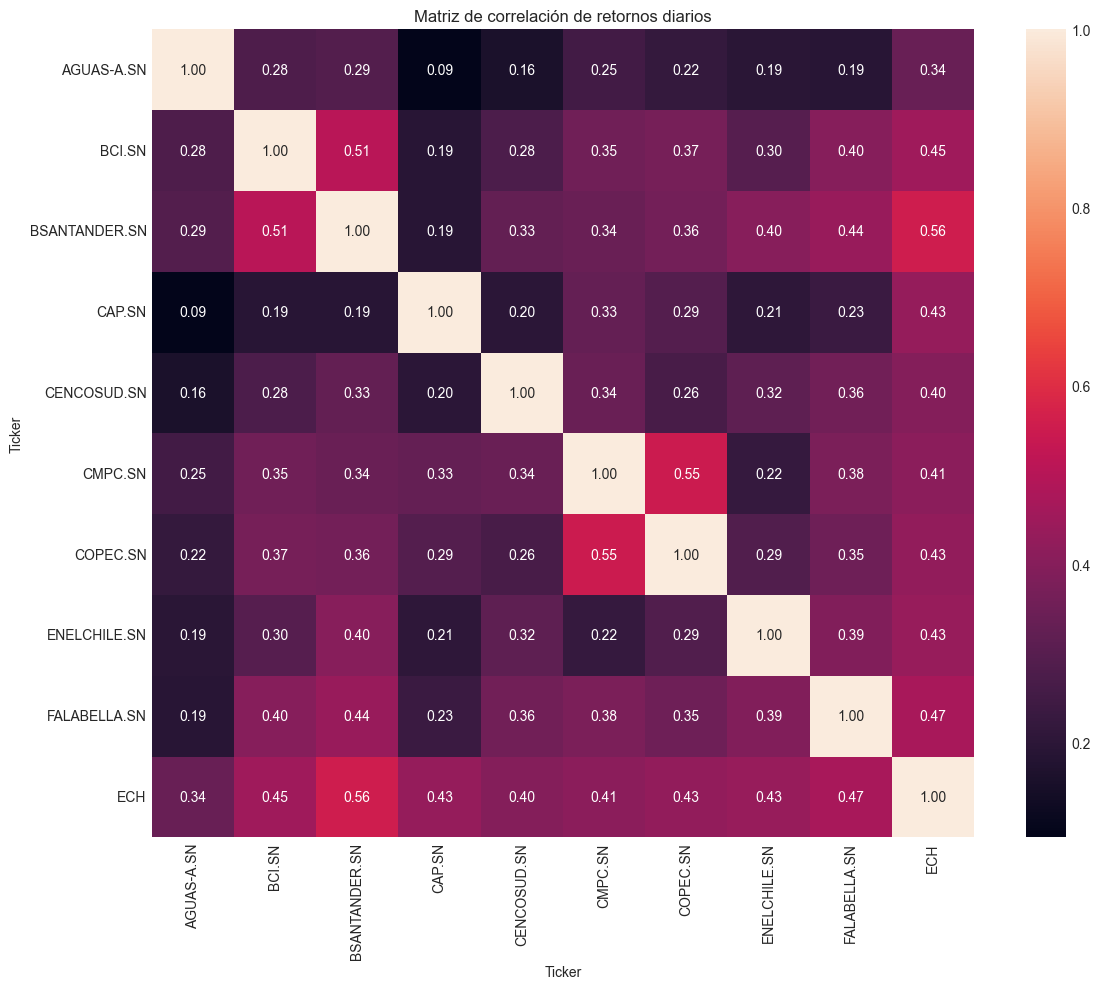

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(retornos_diarios.corr(), annot=True, fmt=".2f")
plt.title("Matriz de correlación de retornos diarios")
plt.tight_layout()

## 9. Conclusiones

### 9.1 Distribución de retornos — leptokurtosis

La comparación entre la distribución empírica (KDE) y la normal teórica revela que todos los activos presentan **exceso de kurtosis positivo** (leptokurtosis): distribuciones más picudas y con colas más gruesas que una normal con la misma media y desviación estándar.

| Activo | Kurtosis (exceso) |
|---|---|
| AGUAS-A.SN | 5.12 |
| ECH | 1.94 |
| CAP.SN | 2.65 |
| CENCOSUD.SN | 1.68 |
| BCI.SN | 1.51 |
| BSANTANDER.SN | 1.22 |
| FALABELLA.SN | 1.06 |
| ENELCHILE.SN | 1.01 |
| CMPC.SN | 0.53 |
| COPEC.SN | 0.39 |

*ECH corresponde al benchmark (iShares MSCI Chile ETF), incluido en el análisis estadístico.*

**Implicación financiera:** los modelos de riesgo basados en distribución normal (como el VaR paramétrico) subestiman la probabilidad de eventos extremos. Las colas más gruesas implican que caídas abruptas ocurren con mayor frecuencia de lo que la normal predice.

---

### 9.2 Test formal de normalidad — Jarque-Bera

El test Jarque-Bera evalúa si la distribución de retornos es estadísticamente compatible con una normal usando skewness y kurtosis conjuntamente. H₀: los retornos siguen una distribución normal.

| Activo | Estadístico JB | p-value | ¿Rechaza normalidad? |
|---|---|---|---|
| AGUAS-A.SN | 529.3 | 1.17×10⁻¹¹⁵ | Sí |
| CAP.SN | 142.1 | 1.40×10⁻³¹ | Sí |
| ECH | 80.8 | 2.82×10⁻¹⁸ | Sí |
| CENCOSUD.SN | 57.9 | 2.66×10⁻¹³ | Sí |
| BCI.SN | 51.1 | 7.94×10⁻¹² | Sí |
| BSANTANDER.SN | 29.7 | 3.50×10⁻⁷ | Sí |
| ENELCHILE.SN | 24.0 | 6.23×10⁻⁶ | Sí |
| FALABELLA.SN | 23.3 | 8.92×10⁻⁶ | Sí |
| CMPC.SN | 14.2 | 8.42×10⁻⁴ | Sí |
| COPEC.SN | 4.5 | 0.107 | **No** |

**Resultado:** 9 de 10 activos rechazan normalidad con p << 0.05, formalizando estadísticamente lo que el análisis visual KDE ya sugería. COPEC.SN es la única excepción (p=0.107), consistente con su kurtosis de 0.39 — la más baja del universo analizado y la única compatible con una distribución normal.

---

### 9.3 Eficiencia de mercado — autocorrelación de retornos

El scatter plot de retorno del día `t` versus retorno del día `t+1` no muestra ninguna estructura en los 10 activos analizados: la nube de puntos es esencialmente aleatoria.

**Conclusión:** los retornos diarios no son predecibles en base al retorno del día anterior, consistente con la **Hipótesis de Mercado Eficiente (EMH)** en su forma débil. Si existiera correlación predecible, los participantes del mercado la explotarían mediante arbitraje hasta eliminarla.

---

### 9.4 Test formal de autocorrelación — Ljung-Box

El test Ljung-Box (lag=1) cuantifica si la autocorrelación observada es estadísticamente distinguible del ruido. H₀: los retornos son independientes entre días consecutivos.

| Activo | Estadístico LB | p-value | ¿Rechaza EMH? |
|---|---|---|---|
| CMPC.SN | 0.02 | 0.881 | No |
| ECH | 0.05 | 0.828 | No |
| ENELCHILE.SN | 0.32 | 0.569 | No |
| AGUAS-A.SN | 0.76 | 0.383 | No |
| BSANTANDER.SN | 0.86 | 0.354 | No |
| FALABELLA.SN | 0.60 | 0.439 | No |
| COPEC.SN | 1.07 | 0.301 | No |
| CENCOSUD.SN | 1.14 | 0.286 | No |
| BCI.SN | 4.93 | 0.026 | **Sí** |
| CAP.SN | 11.78 | 5.98×10⁻⁴ | **Sí** |

**Resultado:** 8 de 10 activos no rechazan H₀, consistente con EMH. Las dos excepciones tienen explicaciones económicas plausibles:

- **BCI.SN** (p=0.026): menor liquidez relativa en el mercado chileno genera rezago en la incorporación de información al precio.
- **CAP.SN** (p=5.98×10⁻⁴): fuerte dependencia del precio del cobre, que se transa 24/7 en London Metal Exchange y Shanghai. El mercado chileno reacciona con rezago a movimientos que ya ocurrieron en mercados internacionales (*price discovery* lento) — la información no se incorpora completamente en un solo día de trading en Santiago.

**Nota metodológica:** con 10 activos testeados a 5% de significancia, se espera al menos 1 rechazo falso por azar. Obtener 2 rechazos con explicaciones económicas plausibles no refuta EMH a nivel de mercado, pero identifica activos donde la eficiencia es más débil — candidatos a estrategias de momentum de corto plazo, que se explorarán en el notebook de backtesting.

---

### 9.5 Agrupamiento de volatilidad (*volatility clustering*)

El scatter plot de volatilidad del día `t` (`|retorno_t|`) versus volatilidad del día `t+1` (`|retorno_{t+1}|`) muestra concentración positiva: días de alta volatilidad tienden a ser seguidos por días de alta volatilidad, y días tranquilos por días tranquilos.

**Explicación:** a diferencia de la dirección del retorno, la magnitud de los movimientos sí es persistente. La información relevante para el mercado llega en rachas, y el comportamiento de manada (*herding*) amplifica el efecto. Este patrón no es arbitrado porque la volatilidad no es directamente transable sin asumir otros riesgos. Es la base empírica de los modelos **GARCH**, que modelan la varianza condicional en el tiempo.

---

### 9.6 Correlación entre activos

La matriz de correlación muestra que los activos del mismo sector tienden a moverse de forma más coordinada entre sí. Las correlaciones más altas se observan entre las acciones del sector bancario (BSANTANDER–BCI) y entre las de retail (FALABELLA–CENCOSUD).

**Implicación para construcción de portafolios:** la diversificación es más efectiva entre sectores que dentro del mismo sector. Un portafolio concentrado en activos de alta correlación ofrece menor reducción de riesgo por activo adicional incluido — principio central de la **teoría de Markowitz**, que se desarrollará en notebooks posteriores.

---

### 9.7 Variación de retornos entre pares de días

El test Ljung-Box aplicado sobre la variación de retorno en pares de días (`r_{t+2} - r_t` vs `r_{t+3} - r_{t+1}`) no muestra autocorrelación significativa en 9 de 10 activos. La excepción es **CAP.SN** (p=0.016), que rechaza la hipótesis de independencia incluso en este análisis de segundo orden.

**Interpretación:** el comportamiento de CAP.SN presenta estructura predecible no solo en retornos diarios (sección 9.4) sino también en la aceleración de retornos entre pares de días. Esto refuerza su identificación como candidato a estrategias de momentum y será explorado en el notebook de backtesting.